<a href="https://colab.research.google.com/github/TusharSharmaji/16_TUSHARSHARMA_D2/blob/main/DL_Optimizer_Comparison_2.3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Optimizer Comparison

Random regression dataset with SGD, RMSprop and Adam comparison.

Training SGD
Training RMSprop


Training Adam



Comparison
SGD: MSE=24143982592.0000, MAE=155383.2656
RMSprop: MSE=9366.9189, MAE=81.7221
Adam: MSE=2936.9487, MAE=45.3551

Best Optimizer: Adam


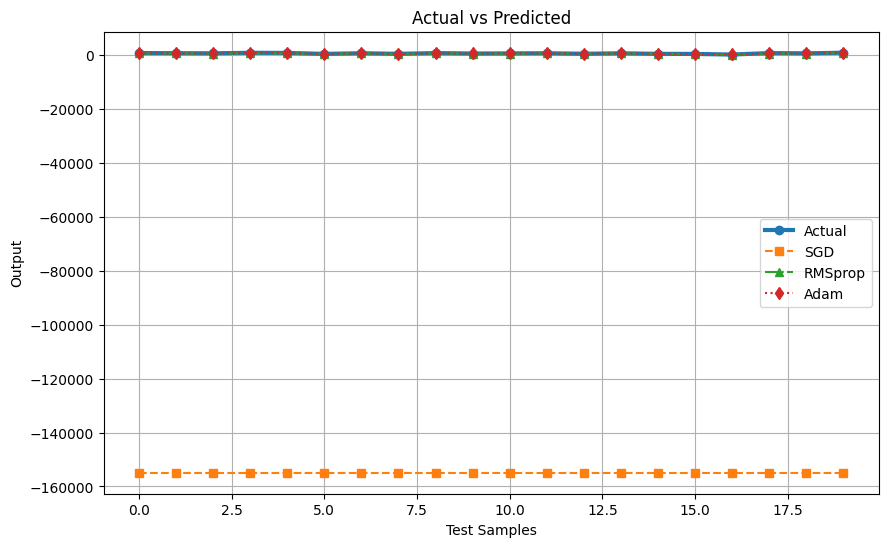

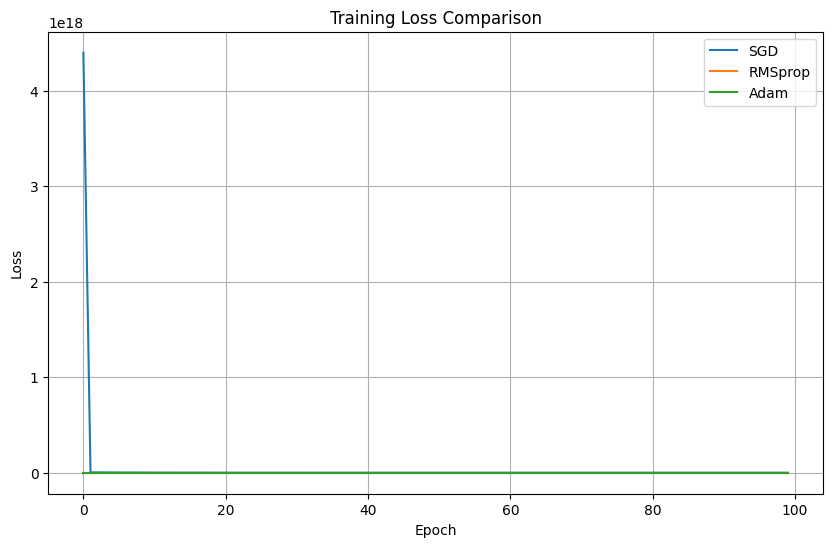

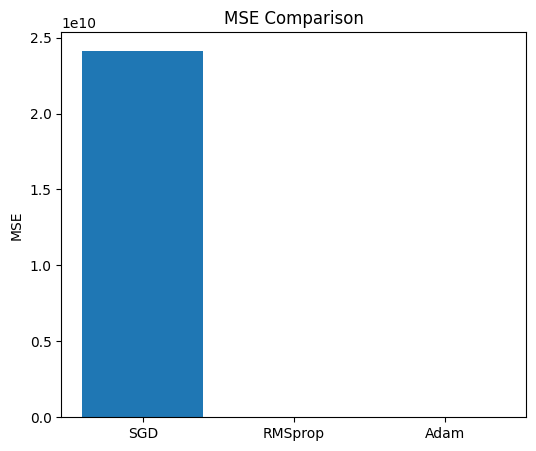

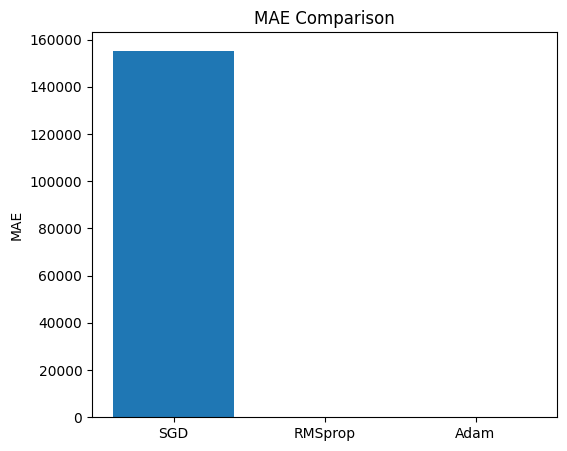

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD,RMSprop,Adam

np.random.seed(42)

# Generate random dataset
X=np.random.randint(1,100,size=(100,3)).astype(float)
noise=np.random.normal(0,8,size=100)
y=2*X[:,0]+3*X[:,1]+4*X[:,2]+noise

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

def build_model(opt):
    model=Sequential([
        Dense(16,activation='relu',input_shape=(3,)),
        Dense(8,activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=opt,loss='mse',metrics=['mae'])
    return model

optimizers={
    'SGD':SGD(learning_rate=0.01),
    'RMSprop':RMSprop(learning_rate=0.001),
    'Adam':Adam(learning_rate=0.001)
}

results={}
histories={}

for name,opt in optimizers.items():
    print(f"Training {name}")
    model=build_model(opt)
    history=model.fit(X_train,y_train,
                      validation_data=(X_test,y_test),
                      epochs=100,
                      verbose=0)
    pred=model.predict(X_test,verbose=0).flatten()
    mse,mae=model.evaluate(X_test,y_test,verbose=0)
    histories[name]=history.history
    results[name]={'prediction':pred,'mse':mse,'mae':mae}

print("\nComparison")
for k,v in results.items():
    print(f"{k}: MSE={v['mse']:.4f}, MAE={v['mae']:.4f}")

best=min(results.items(),key=lambda x:x[1]['mse'])
print("\nBest Optimizer:",best[0])

plt.figure(figsize=(10,6))
plt.plot(y_test,marker='o',linewidth=3,label='Actual')
plt.plot(results['SGD']['prediction'],'--s',label='SGD')
plt.plot(results['RMSprop']['prediction'],'-.^',label='RMSprop')
plt.plot(results['Adam']['prediction'],':d',label='Adam')
plt.title('Actual vs Predicted')
plt.xlabel('Test Samples')
plt.ylabel('Output')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
for name in optimizers:
    plt.plot(histories[name]['loss'],label=name)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.bar(list(results.keys()),[results[k]['mse'] for k in results])
plt.title('MSE Comparison')
plt.ylabel('MSE')
plt.show()

plt.figure(figsize=(6,5))
plt.bar(list(results.keys()),[results[k]['mae'] for k in results])
plt.title('MAE Comparison')
plt.ylabel('MAE')
plt.show()
